In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts
from scipy.special import gamma
from scipy.optimize import minimize_scalar

In [ ]:
df = pd.read_csv("results/eth/eth_L10_N7_seed1234.csv", comment="#")
print(f"{len(df)} eigenstates")
df.head()

## ETH plot

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.scatter(df["energy"], df["O_expval"], s=1, alpha=0.4, linewidths=0)

ax.set_xlabel(r"$E_n$")
ax.set_ylabel(r"$\langle E_n | \hat{n}_5 \hat{n}_6 | E_n \rangle$")
ax.set_title(r"ETH plot — $L=10$, $N=7$, $W=0.2$, seed 1234")

plt.tight_layout()
plt.savefig("results/eth/eth_L10_N7_seed1234.pdf", dpi=150)
plt.show()

## Level spacing statistics

In [4]:
def level_spacing(evals, deg=10):
    """Unfold spectrum via polynomial fit to staircase, return normalised spacings."""
    evals = np.sort(evals)
    D = len(evals)
    cut = int(0.10 * D)
    evals_bulk = evals[cut : D - cut]
    N_bulk = np.arange(1, len(evals_bulk) + 1)
    coeffs = np.polyfit(evals_bulk, N_bulk, deg)
    p = np.poly1d(coeffs)
    eps = p(evals_bulk)
    return np.diff(eps)

def brody_b(beta):
    return gamma((beta + 2) / (beta + 1)) ** (beta + 1)

def brody_pdf(s, beta):
    s = np.asarray(s)
    b = brody_b(beta)
    return (beta + 1) * b * (s ** beta) * np.exp(-b * s ** (beta + 1))

def fit_brody_beta_mle(s):
    s = np.asarray(s, dtype=float)
    s = s[s > 0]
    def neg_loglike(beta):
        if beta < 0 or beta > 1:
            return np.inf
        return -np.sum(np.log(brody_pdf(s, beta) + 1e-300))
    result = minimize_scalar(neg_loglike, bounds=(0, 1), method="bounded")
    return result.x, result

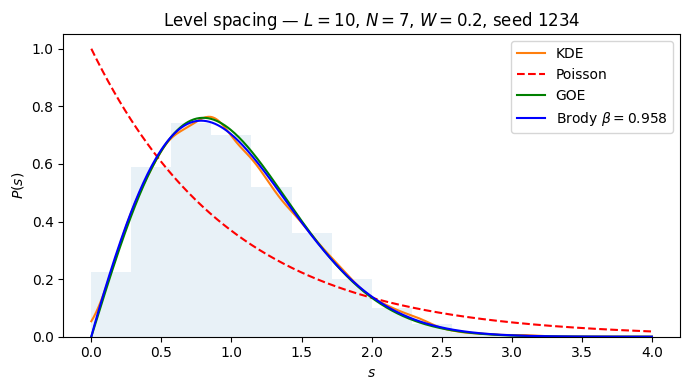

Brody beta = 0.9581  (0=Poisson/MBL, 1=GOE/ETH)


In [5]:
evals = df["energy"].to_numpy()
s = level_spacing(evals)
beta_fit, _ = fit_brody_beta_mle(s)

bin_number = int(np.log2(len(s)) + 1)
s_vals  = np.linspace(0, 4, 400)
poisson = np.exp(-s_vals)
goe     = (np.pi * s_vals / 2) * np.exp(-np.pi * s_vals**2 / 4)

kde   = sts.gaussian_kde(s)
xgrid = np.linspace(0, 4, 500)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(s, bins=bin_number, density=True, range=(0, 4), alpha=0.1)
ax.plot(xgrid, kde(xgrid), label="KDE")
ax.plot(s_vals, poisson, "r--", label="Poisson")
ax.plot(s_vals, goe,     "g-",  label="GOE")
ax.plot(s_vals, brody_pdf(s_vals, beta_fit), "b-",
        label=rf"Brody $\beta={beta_fit:.3f}$")

ax.set_xlabel(r"$s$")
ax.set_ylabel(r"$P(s)$")
ax.set_title(r"Level spacing — $L=10$, $N=7$, $W=0.2$, seed 1234")
ax.legend()

plt.tight_layout()
# plt.savefig("results/level_spacing_L10_N7_seed1234.pdf", dpi=150)
plt.show()

print(f"Brody beta = {beta_fit:.4f}  (0=Poisson/MBL, 1=GOE/ETH)")